# Eval facies inference with Inversion Reults

In [ ]:
# 1. Load saved inference results and the RMS survey
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

STYLE_MATCHING_DIR = repo_root / "style-matching"
if str(STYLE_MATCHING_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_MATCHING_DIR))

from infer import SUBSAMPLE_FACTOR, HORIZON_FILE, load_h05_grid, subsample_grid

RUN_TIMESTAMP = "20260818_102941"
HORIZON_TAG = Path(HORIZON_FILE).stem
OUTPUT_DIR = Path("/mnt/sda_data/tharitt/diffsim/results") / f"eval_karawake_{RUN_TIMESTAMP}"

hrz = "seq3"
RESULT_PATH = OUTPUT_DIR / f"arthit_inference_{hrz}-rms_full_sub2_p64_s16_styleh05_sub1_samples8_steps100_eta0.npz"
HORIZON_PATH = Path(f"./style-matching/eval-karawake/{hrz}-rms")
INVERSION_SAND_PATH = Path(f"./style-matching/eval-karawake/{hrz}-sandprob")

SUBSAMPLE_FACTOR = 2

# None -> use `probabilities` from Cell 1; otherwise a Petrel *_prob_sand.txt exported on the same subsampled grid
INFERENCE_SAND_PATH = None
OURS_THRESHOLD = 0.6
INVERSION_THRESHOLD = 0.6
SCATTER_CATEGORIES = ("TP", "FN")

if not RESULT_PATH.is_file():
    raise FileNotFoundError(f"Saved inference result not found: {RESULT_PATH}")
if not HORIZON_PATH.is_file():
    raise FileNotFoundError(f"horizon input file not found: {HORIZON_PATH}")

with np.load(RESULT_PATH) as saved:
    probabilities = saved["probabilities"]
    most_likely = saved["most_likely"]
    row_min = int(saved["row_min"])
    col_min = int(saved["col_min"])
    x_affine = saved["x_affine"]
    y_affine = saved["y_affine"]
    facies_names = [str(name) for name in saved["facies_names"]]

full_rms_grid, full_georef = load_h05_grid(HORIZON_PATH)
rms_grid, georef = subsample_grid(full_rms_grid, full_georef, SUBSAMPLE_FACTOR)

if rms_grid.shape != most_likely.shape:
    raise ValueError(
        f"Subsampled RMS shape {rms_grid.shape} does not match prediction shape {most_likely.shape}; "
        "check SUBSAMPLE_FACTOR."
    )

covered = most_likely >= 0
print(f"Loaded: {RESULT_PATH}")
print(f"Horizon file: {HORIZON_FILE}")
print(f"Full-resolution RMS shape: {full_rms_grid.shape}")
print(f"Subsampled RMS shape: {rms_grid.shape} (factor {SUBSAMPLE_FACTOR})")
print(f"Most-likely map shape: {most_likely.shape}")
print(f"Probability map shape: {probabilities.shape}")
print(f"Covered cells: {covered.sum():,}")
print("Facies counts:", dict(zip(*np.unique(most_likely[covered], return_counts=True))))


Loaded: /mnt/sda_data/tharitt/diffsim/results/eval_karawake_20260818_102941/arthit_inference_seq3-rms_full_sub2_p64_s16_styleh05_sub1_samples8_steps100_eta0.npz
Horizon file: seq2-rms
Full-resolution RMS shape: (602, 969)
Subsampled RMS shape: (301, 485) (factor 2)
Most-likely map shape: (301, 485)
Probability map shape: (3, 301, 485)
Covered cells: 97,133
Facies counts: {np.int8(0): np.int64(47284), np.int8(1): np.int64(47078), np.int8(2): np.int64(2771)}


In [15]:
# 2. Plot RMS, most-likely facies, and separate per-facies probabilities
FACIES_COLORS = ["#3E3E3E", "#E6B422", "#8FBBD9"]
facies_cmap = ListedColormap(FACIES_COLORS)
PLOT_SIZE = (16, 24)

facies_names = {
    0: "shale",
    1: "sand",
    2: "silt",
}


# 3. Helpers: map sand-probability files onto the prediction grid and compare them
from matplotlib.colors import ListedColormap

SAND_INDEX = 1
# category code = 2 * inversion_is_sand + ours_is_sand
CATEGORY_NAMES = ["TN", "FP", "FN", "TP"]
CATEGORY_COLORS = ["#3E3E3E", "#D95F02", "#7570B3", "#E6B422"]
category_cmap = ListedColormap(CATEGORY_COLORS)

_POINT_CACHE = {}


def read_petrel_points(path):
    """Read (x, y, z) from a Petrel scattered-data file, cached so threshold changes are instant."""
    path = Path(path).resolve()
    key = (str(path), path.stat().st_mtime)
    if key not in _POINT_CACHE:
        _POINT_CACHE[key] = np.loadtxt(path, comments="#", usecols=(0, 1, 2), dtype=np.float64)
    return _POINT_CACHE[key]


def points_to_grid(points, georef, shape):
    """Block-average scattered (x, y, z) points onto prediction-grid cells using the georef affine."""
    x_aff, y_aff = georef["x_affine"], georef["y_affine"]
    inverse = np.linalg.inv(np.array([[x_aff[1], x_aff[2]], [y_aff[1], y_aff[2]]]))
    cols, rows = np.floor(inverse @ np.stack([points[:, 0] - x_aff[0], points[:, 1] - y_aff[0]]) + 0.5).astype(np.int64)
    rows -= int(georef["row_min"])
    cols -= int(georef["col_min"])
    inside = (rows >= 0) & (rows < shape[0]) & (cols >= 0) & (cols < shape[1]) & np.isfinite(points[:, 2])
    flat = rows[inside] * shape[1] + cols[inside]
    size = shape[0] * shape[1]
    totals = np.bincount(flat, weights=points[inside, 2], minlength=size)
    counts = np.bincount(flat, minlength=size)
    grid = np.full(size, np.nan, dtype=np.float64)
    np.divide(totals, counts, out=grid, where=counts > 0)
    return grid.reshape(shape)


def classify(ours, inversion, valid, ours_threshold, inversion_threshold):
    valid = valid & np.isfinite(ours) & np.isfinite(inversion)
    code = 2 * (inversion > inversion_threshold).astype(np.int8) + (ours > ours_threshold).astype(np.int8)
    return np.where(valid, code, -1).astype(np.int8)


def confusion_from_category(category):
    counts = np.bincount(category[category >= 0], minlength=4)
    # rows: inversion (non-sand, sand); cols: ours (non-sand, sand)
    return counts.reshape(2, 2)


def grid_corner_xy(georef, shape):
    # the grid is rotated, so cell corners come from the full affine rather than an imshow extent
    rows, cols = np.meshgrid(
        np.arange(shape[0] + 1) - 0.5 + georef["row_min"],
        np.arange(shape[1] + 1) - 0.5 + georef["col_min"],
        indexing="ij",
    )
    x_aff, y_aff = georef["x_affine"], georef["y_affine"]
    return x_aff[0] + x_aff[1] * cols + x_aff[2] * rows, y_aff[0] + y_aff[1] * cols + y_aff[2] * rows


def plot_sand_maps(rms, rms_label, ours, inversion, category, ours_label, inversion_label, ours_threshold, inversion_threshold, georef, rms_vmax=1000):
    x_corner, y_corner = grid_corner_xy(georef, rms.shape)
    x_span = np.ptp(x_corner)
    y_span = np.ptp(y_corner)
    fig, axes = plt.subplots(2, 2, figsize=(24, 20 * y_span / x_span + 3), constrained_layout=True)
    axes = axes.ravel()

    def draw(axis, grid, **kwargs):
        image = axis.pcolormesh(x_corner, y_corner, np.ma.masked_invalid(grid), shading="flat", rasterized=True, **kwargs)
        axis.set_aspect("equal")
        return image

    rms_image = draw(axes[0], rms, cmap="rainbow", vmax=rms_vmax)
    axes[0].set_title(f"{rms_label}\nRMS amplitude", fontsize=14)
    fig.colorbar(rms_image, ax=axes[0], shrink=0.7, label="RMS amplitude")

    for axis, grid, title in [
        (axes[1], ours, f"Ours: {ours_label}"),
        (axes[2], inversion, f"Inversion: {inversion_label}"),
    ]:
        image = draw(axis, grid, cmap="cividis", vmin=0, vmax=1)
        axis.set_title(f"{title}\nsand probability", fontsize=14)
        fig.colorbar(image, ax=axis, shrink=0.7, label="P(sand)")

    draw(axes[3], np.where(category >= 0, category, np.nan), cmap=category_cmap, vmin=-0.5, vmax=3.5)
    axes[3].set_title(f"Agreement (ours > {ours_threshold}, inversion > {inversion_threshold})", fontsize=14)
    counts = np.bincount(category[category >= 0], minlength=4)
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[code], label=f"{CATEGORY_NAMES[code]} ({counts[code]:,})")
        for code in (3, 0, 1, 2)
    ]
    axes[3].legend(handles=handles, loc="upper right", fontsize=11)
    for axis in axes:
        axis.set_xlabel("X (m)")
        axis.set_ylabel("Y (m)")
        axis.ticklabel_format(useOffset=False, style="plain")
    plt.show()


def plot_confusion(confusion, ours_threshold, inversion_threshold):
    total = confusion.sum()
    row_pct = confusion / np.maximum(confusion.sum(axis=1, keepdims=True), 1)
    fig, axis = plt.subplots(figsize=(6, 5), constrained_layout=True)
    axis.imshow(row_pct, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            name = CATEGORY_NAMES[2 * i + j]
            axis.text(
                j, i, f"{name}\n{confusion[i, j]:,}\n{row_pct[i, j]:.1%} of row",
                ha="center", va="center", fontsize=12, color="white" if row_pct[i, j] > 0.5 else "black",
            )
    axis.set_xticks([0, 1], [f"non-sand (≤{ours_threshold})", f"sand (>{ours_threshold})"])
    axis.set_yticks([0, 1], [f"non-sand (≤{inversion_threshold})", f"sand (>{inversion_threshold})"])
    axis.set_xlabel("Ours (inference)")
    axis.set_ylabel("Inversion")
    axis.set_title(f"Sand confusion matrix (n = {total:,})")
    plt.show()

    tn, fp, fn, tp = confusion.ravel()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    print(f"Accuracy : {(tp + tn) / max(total, 1):.3f}")
    print(f"Precision: {precision:.3f}  (of cells we call sand, fraction inversion also calls sand)")
    print(f"Recall   : {recall:.3f}  (of inversion sand cells, fraction we also call sand)")
    print(f"F1       : {2 * precision * recall / max(precision + recall, 1e-12):.3f}")


def plot_probability_scatter(ours, inversion, category, ours_threshold, inversion_threshold, categories=("TP", "FN")):
    fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6.5), constrained_layout=True, squeeze=False)
    valid = category >= 0
    y_low = min(0.0, float(np.nanmin(inversion[valid])))
    y_high = max(1.0, float(np.nanmax(inversion[valid])))
    for axis, name in zip(axes[0], categories):
        code = CATEGORY_NAMES.index(name)
        selected = category == code
        x, y = ours[selected], inversion[selected]
        axis.scatter(x, y, s=2, alpha=0.25, color=CATEGORY_COLORS[code], rasterized=True)
        axis.axvline(ours_threshold, color="k", ls="--", lw=1)
        axis.axhline(inversion_threshold, color="k", ls="--", lw=1)
        axis.plot([0, 1], [0, 1], color="gray", lw=1)
        r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
        axis.set_title(f"{name}: n = {len(x):,}, Pearson r = {r:.3f}")
        axis.set_xlim(0, 1)
        axis.set_ylim(y_low, y_high)
        axis.set_xlabel("Ours: sand probability (inference)")
        axis.set_ylabel("Inversion: sand probability")
        axis.grid(alpha=0.3)
    plt.show()


Ours cells: 97,133 | inversion cells: 97,133 | overlap: 97,133
Inversion P(sand) range in overlap: [0.000, 1.220]


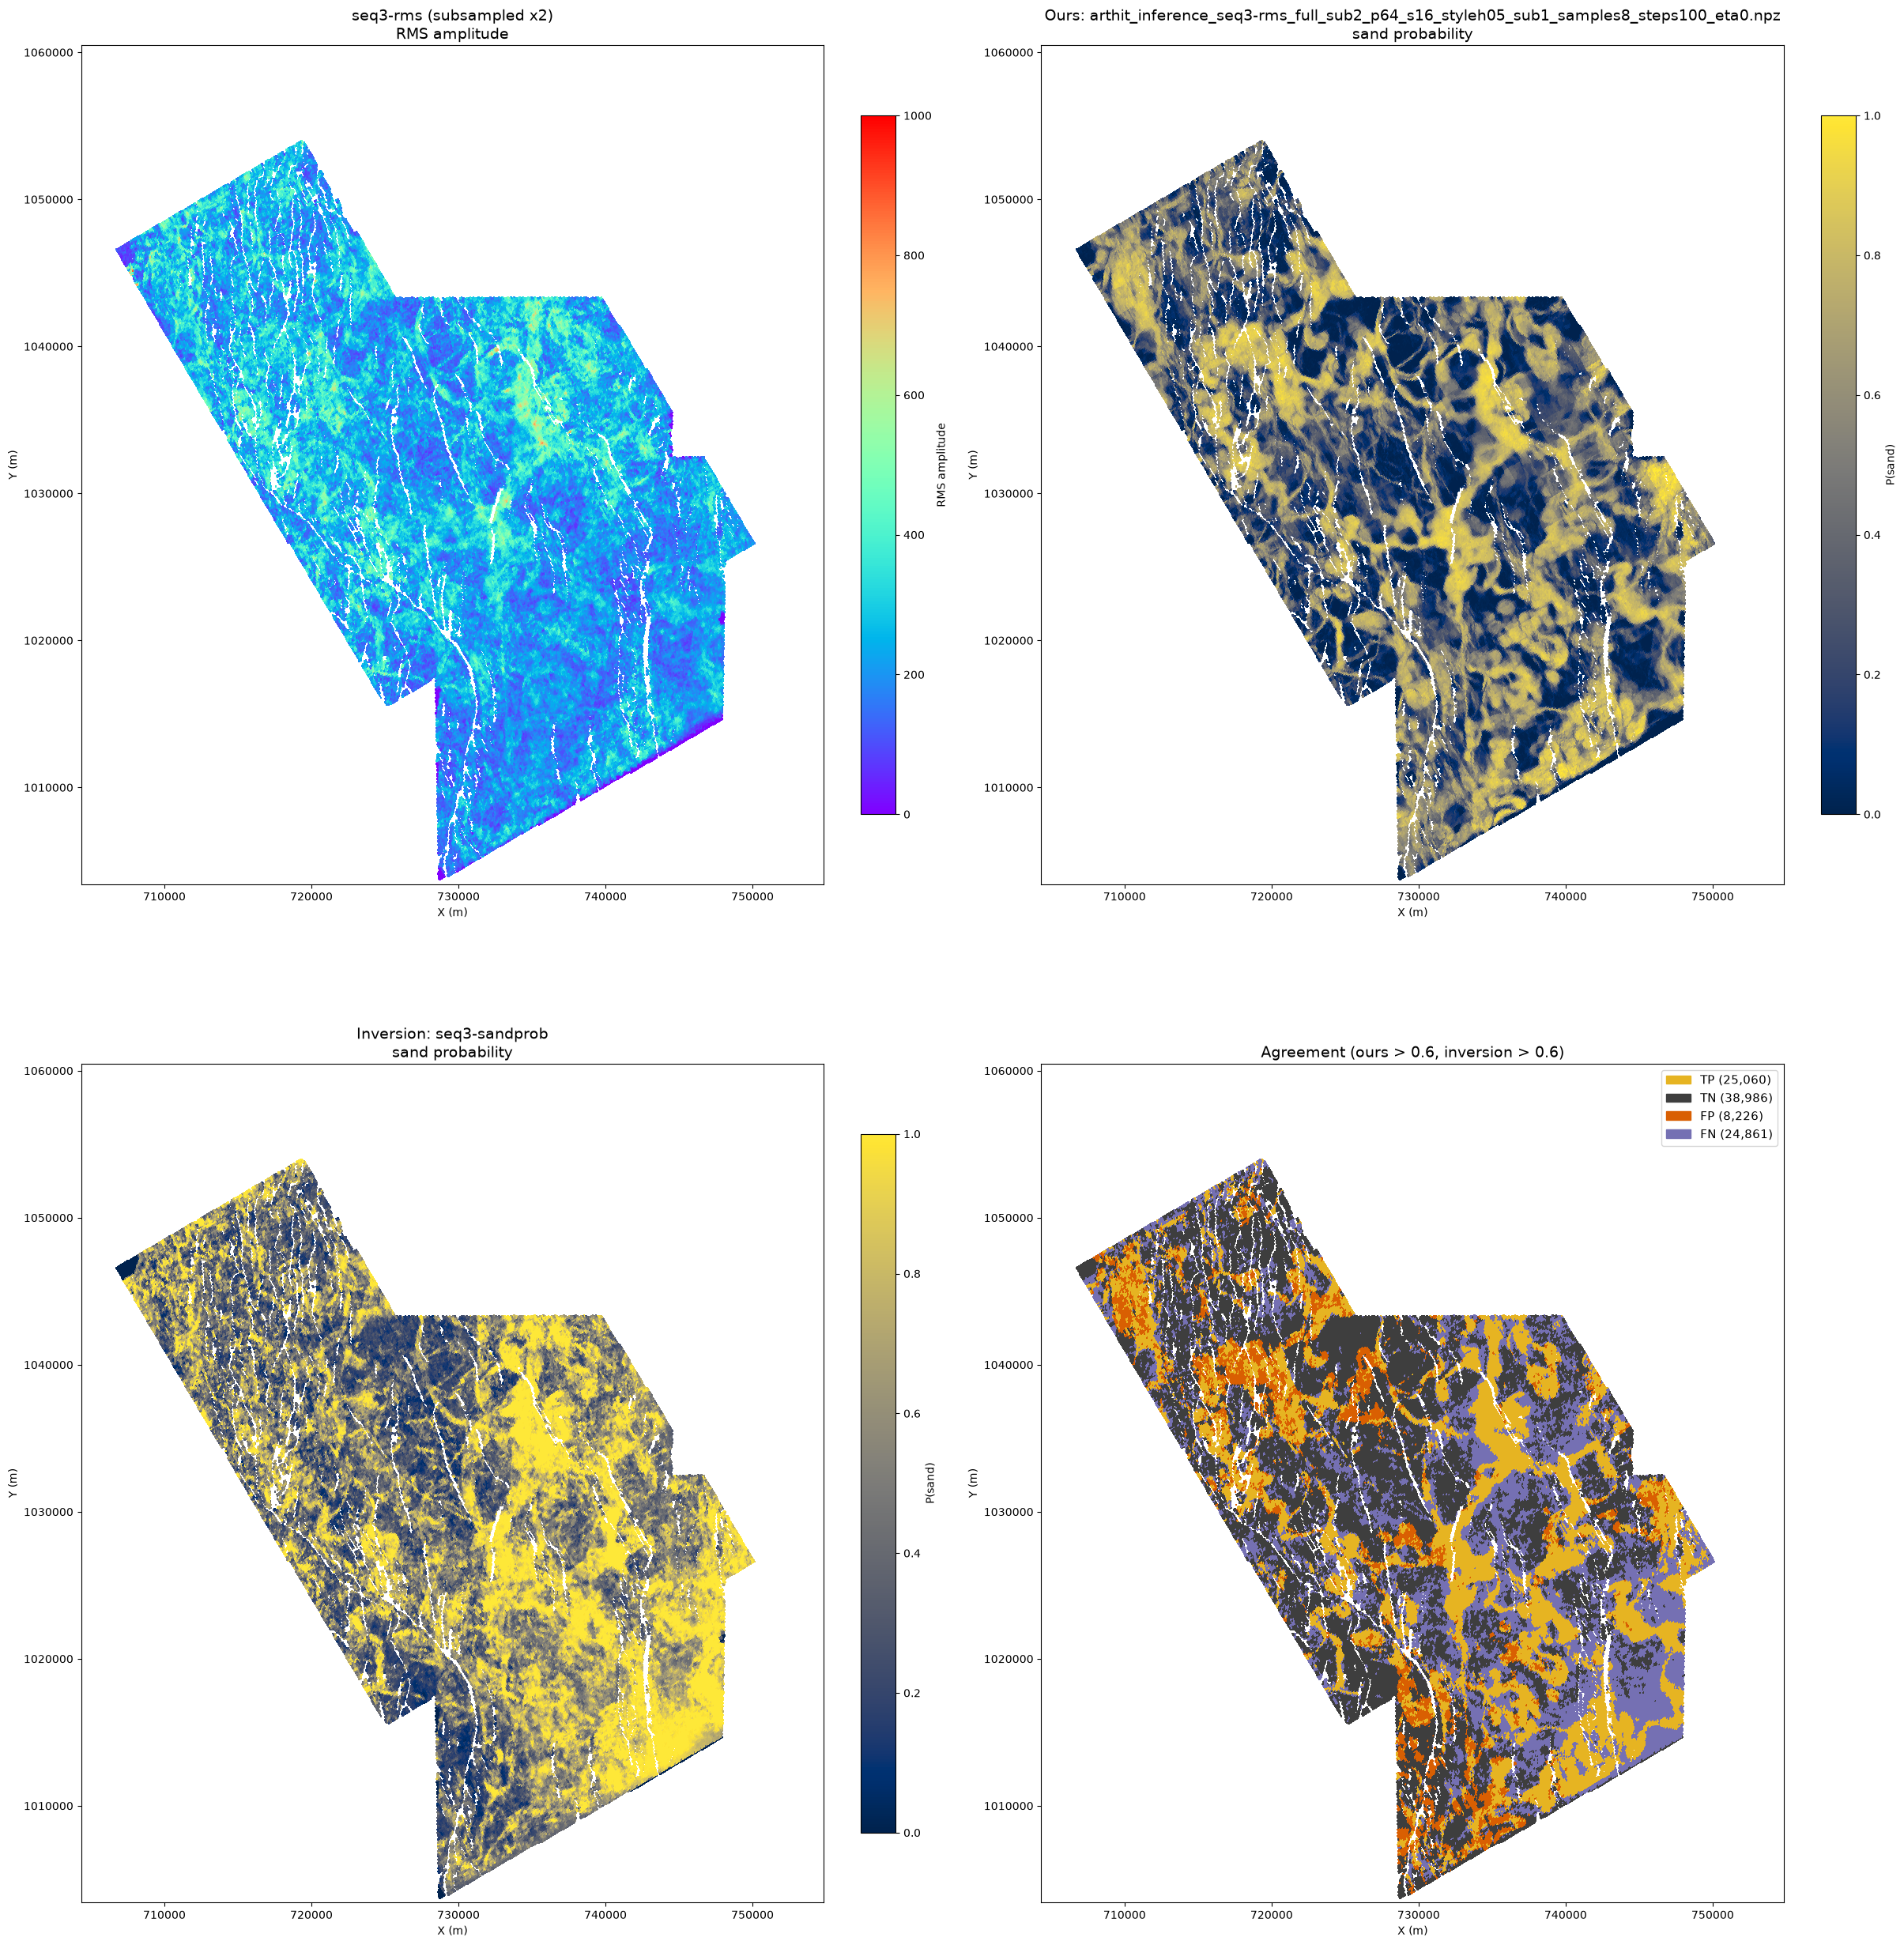

In [16]:
if INFERENCE_SAND_PATH is None:
    ours_sand = np.where(covered, probabilities[SAND_INDEX], np.nan).astype(np.float64)
    ours_label = RESULT_PATH.name
else:
    ours_sand = points_to_grid(read_petrel_points(INFERENCE_SAND_PATH), georef, most_likely.shape)
    ours_label = Path(INFERENCE_SAND_PATH).name

inversion_sand = points_to_grid(read_petrel_points(INVERSION_SAND_PATH), georef, most_likely.shape)

sand_category = classify(ours_sand, inversion_sand, np.isfinite(ours_sand), OURS_THRESHOLD, INVERSION_THRESHOLD)
sand_confusion = confusion_from_category(sand_category)

overlap = sand_category >= 0
print(f"Ours cells: {np.isfinite(ours_sand).sum():,} | inversion cells: {np.isfinite(inversion_sand).sum():,} | overlap: {overlap.sum():,}")
print(f"Inversion P(sand) range in overlap: [{np.nanmin(inversion_sand[overlap]):.3f}, {np.nanmax(inversion_sand[overlap]):.3f}]")

plot_sand_maps(
    rms_grid, f"{HORIZON_PATH.name} (subsampled x{SUBSAMPLE_FACTOR})",
    ours_sand, inversion_sand, sand_category, ours_label, INVERSION_SAND_PATH.name, OURS_THRESHOLD, INVERSION_THRESHOLD,
    georef,
)

#plot_confusion(sand_confusion, OURS_THRESHOLD, INVERSION_THRESHOLD)
#plot_probability_scatter(ours_sand, inversion_sand, sand_category, OURS_THRESHOLD, INVERSION_THRESHOLD, SCATTER_CATEGORIES)